# 04 — Avaliação e Interpretação

# 0 — Preparação dos dados (recriando pré-processamento)

In [1]:
import pandas as pd
import numpy as np

df_credit = pd.read_csv("../data/raw/credit_record.csv")
df_application = pd.read_csv("../data/raw/application_record.csv")

##**0.1 Transformação necessária do STATUS para número**

In [2]:
df_credit['STATUS_NUM'] = df_credit['STATUS'].replace({
    'C': -1,
    'X': -1
}).astype(int)

##**0.2 Recriando a regra 3**

In [3]:
TARGET3 = (
    df_credit
    .groupby('ID')
    .agg(
        TOTAL_MESES=('STATUS_NUM', 'count'),
        MESES_STATUS_0=('STATUS_NUM', lambda x: (x == 0).sum()),
        MESES_STATUS_1=('STATUS_NUM', lambda x: (x == 1).sum()),
        MESES_STATUS_2_MAIS=('STATUS_NUM', lambda x: (x >= 2).sum())
    )
    .reset_index()
)

TARGET3['TARGET'] = (
    (TARGET3['MESES_STATUS_1'] >= 2) |
    (TARGET3['MESES_STATUS_2_MAIS'] >= 1) |
    (TARGET3['MESES_STATUS_0'] >= 6)
).astype(int)

#**Definição final da variável-alvo *TARGET***

O cliente será classificado como de **maior risco (TARGET = 1)** quando apresentar:

STATUS = 1: de 30 a 59 dias, pelo menos 2 vezes (recorrência de atraso média) no período de 61 meses OU

STATUS >= 2, 60 dias ou mais, pelo menos uma vez no período de 61 meses (gravidade do atraso) OU

STATUS = 0, de 1 a 29 dias pelo menos 6 vezes (recorrência de atraso moderada) no período de 61 meses




**Caso nenhuma dessas condições seja satisfeita, o cliente será classificado como de menor risco (TARGET = 0)**.

# **0.3 Análise Exploratória de Dados - application_record**

In [4]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [5]:
df_application.shape

(438557, 18)

In [6]:
#verificando dados em branco
df_application.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [7]:
#resumo de campos

for coluna in df_application.select_dtypes(include='object').columns:
    print(f'\n===== {coluna} =====')
    print(df_application[coluna].value_counts(dropna=False))


===== CODE_GENDER =====
CODE_GENDER
F    294440
M    144117
Name: count, dtype: int64

===== FLAG_OWN_CAR =====
FLAG_OWN_CAR
N    275459
Y    163098
Name: count, dtype: int64

===== FLAG_OWN_REALTY =====
FLAG_OWN_REALTY
Y    304074
N    134483
Name: count, dtype: int64

===== NAME_INCOME_TYPE =====
NAME_INCOME_TYPE
Working                 226104
Commercial associate    100757
Pensioner                75493
State servant            36186
Student                     17
Name: count, dtype: int64

===== NAME_EDUCATION_TYPE =====
NAME_EDUCATION_TYPE
Secondary / secondary special    301821
Higher education                 117522
Incomplete higher                 14851
Lower secondary                    4051
Academic degree                     312
Name: count, dtype: int64

===== NAME_FAMILY_STATUS =====
NAME_FAMILY_STATUS
Married                 299828
Single / not married     55271
Civil marriage           36532
Separated                27251
Widow                    19675
Name: count, dty

In [8]:
#verificar registros duplicados
df_application.duplicated().sum()

np.int64(0)

## **0.5 - Pré-processamento - application_record**

In [9]:
#preenchendo campos em branco de ocupação como "not reported"
df_application['OCCUPATION_TYPE'] = df_application['OCCUPATION_TYPE'].fillna('Not reported')
df_application.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [10]:
#Tratando coluna DAYS_BIRTH
df_application['DAYS_BIRTH'].describe()

,DAYS_BIRTH
count,438557.000000
mean,-15997.904649
std,4185.030007
min,-25201.000000
25%,-19483.000000
50%,-15630.000000
75%,-12514.000000
max,-7489.000000


```
# Observações:
1- DAYS_BIRTH demonstrou totalidade dos valores negativos
```

In [11]:
#Criando coluna AGE com base na idade em dias DAYS_BIRTH
df_application['AGE'] = (-df_application['DAYS_BIRTH'] / 365.25).round(1)

In [12]:
df_application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Not reported,2.0,32.9
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Not reported,2.0,32.9
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58.8
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52.3
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52.3


In [13]:
#Tratando coluna DAYS_EMPLOYED
df_application['DAYS_EMPLOYED'].describe()

,DAYS_EMPLOYED
count,438557.000000
mean,60563.675328
std,138767.799647
min,-17531.000000
25%,-3103.000000
50%,-1467.000000
75%,-371.000000
max,365243.000000


```
# Observações:
1- DAYS_EMPLOYED demonstrou valores mínimos negativos e máximos positivos. Análise relevante antes do tratamento
```

In [14]:
# verificando quantidade de valores positivos e negativos
(df_application['DAYS_EMPLOYED'] < 0).value_counts()

,count
DAYS_EMPLOYED,
True,363228
False,75329


In [15]:
#Investigando quais valores são positivos
df_application_positive = df_application[df_application['DAYS_EMPLOYED'] >= 0]
df_application_positive['DAYS_EMPLOYED'].value_counts().head(20)

,count
DAYS_EMPLOYED,
365243,75329


```
# Observações:
1- Todos os valores positivos são DAYS_EMPLOYED = 365243 ou 365243/365,25≈ 1000 anos
```

In [16]:
#Investigando a profissão dos valores positivos
df_application[df_application['DAYS_EMPLOYED'] == 365243]['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,75329


In [17]:
pd.crosstab(
    df_application['NAME_INCOME_TYPE'],
    df_application['DAYS_EMPLOYED'] >= 0,
    normalize='index'
) * 100

DAYS_EMPLOYED,False,True
NAME_INCOME_TYPE,,
Commercial associate,100.000000,0.000000
Pensioner,0.217239,99.782761
State servant,100.000000,0.000000
Student,100.000000,0.000000
Working,100.000000,0.000000


```
# Observações:
1- Os valores positivos correspondem aos pensionistas. Criar variável com registros positivos ajustados como ausentes
```



In [18]:
#criando variável DAYS_EMPLOYED_CLEAN ajustando os valores positivos como ausentes

df_application['DAYS_EMPLOYED_CLEAN'] = df_application['DAYS_EMPLOYED'].where(
    df_application['DAYS_EMPLOYED'] < 0
)
df_application['DAYS_EMPLOYED_CLEAN']

,DAYS_EMPLOYED_CLEAN
0,-4542.0
1,-4542.0
2,-1134.0
3,-3051.0
4,-3051.0
...,...
438552,NaN
438553,-3007.0
438554,-372.0
438555,NaN


In [19]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [20]:
#transformar vaiáveis numéricas de dias para anos e deixar os vazios como 60 para demonstrar pensionistas
df_application['YEARS_EMPLOYED'] = (
    -df_application['DAYS_EMPLOYED_CLEAN'] / 365.25
).fillna(60)
df_application[['YEARS_EMPLOYED', 'DAYS_EMPLOYED']].round(1)

,YEARS_EMPLOYED,DAYS_EMPLOYED
0,12.4,-4542
1,12.4,-4542
2,3.1,-1134
3,8.4,-3051
4,8.4,-3051
...,...,...
438552,60.0,365243
438553,8.2,-3007
438554,1.0,-372
438555,60.0,365243


In [21]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [22]:
#análise descritiva de anos de emprego
df_application['YEARS_EMPLOYED'].describe()

,YEARS_EMPLOYED
count,438557.000000
mean,16.253923
std,20.799711
min,0.032854
25%,2.992471
50%,6.880219
75%,16.013689
max,60.000000


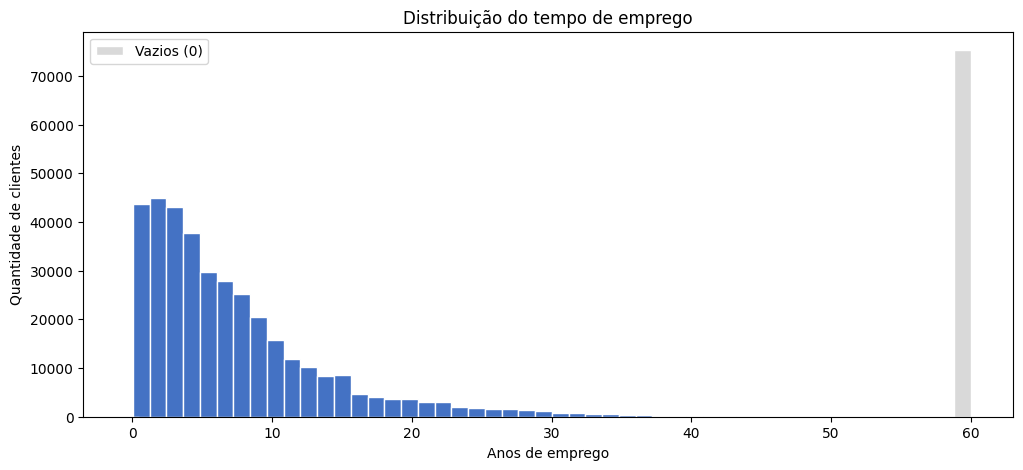

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Valores preenchidos
dados = df_application['YEARS_EMPLOYED'].dropna()

# Quantidade de valores vazios
qtd_vazios = df_application['YEARS_EMPLOYED'].isna().sum()

# Histograma dos valores preenchidos
counts, bins = np.histogram(dados, bins=50)

# Cores das barras
cores = [
    '#D9D9D9' if bin_left >= 50 else '#4472C4'
    for bin_left in bins[:-1]
]

plt.figure(figsize=(12, 5))

# Histograma
plt.bar(
    bins[:-1],
    counts,
    width=np.diff(bins),
    align='edge',
    color=cores,
    edgecolor='white'
)

# Barra dos valores vazios
plt.bar(
    0,
    qtd_vazios,
    width=1,
    color='#D9D9D9',
    edgecolor='white',
    label=f'Vazios ({qtd_vazios:,})'
)

plt.xlabel('Anos de emprego')
plt.ylabel('Quantidade de clientes')
plt.title('Distribuição do tempo de emprego')
plt.legend()

plt.show()

```
# Observações:
1- Concentração em até 10 anos de emprego com os pensionistas separados sem informação
```



# **0.6 Pré-processamento - Unir tabelas de dados dos clientes e de informações de TARGET**

In [24]:
#inner apenas clientes que possuem informações de cadastro + histórico de crédito com TARGET.
df_model = df_application.merge(
    TARGET3[['ID', 'TARGET']],
    on='ID',
    how='inner'
)

In [25]:
#tamanho da tabela por registros coincidentes
df_model.shape

(36457, 22)

In [26]:
df_model.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,DAYS_EMPLOYED_CLEAN,YEARS_EMPLOYED,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Not reported,2.0,32.9,-4542.0,12.435318,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Not reported,2.0,32.9,-4542.0,12.435318,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,1,0,0,0,Security staff,2.0,58.8,-1134.0,3.104723,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,52.3,-3051.0,8.353183,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,52.3,-3051.0,8.353183,0


In [27]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

In [28]:
df_model['TARGET'].value_counts(normalize=True) * 100

,proportion
TARGET,
1,56.921853
0,43.078147


# **0.7 Pré-processamento - definindo variáveis do modelo**

In [29]:
#-excluir a variável ID, DAYS_BIRTH, DAYS_EMPLOYED, DAYS_EMPLOYED_CLEAN e'FLAG_MOBIL (todos os clientes têm celular)  do modelo
df_modela = df_model.drop(columns=['ID', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_EMPLOYED_CLEAN', 'FLAG_MOBIL']).copy()

In [30]:
df_modela.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CODE_GENDER          36457 non-null  object 
 1   FLAG_OWN_CAR         36457 non-null  object 
 2   FLAG_OWN_REALTY      36457 non-null  object 
 3   CNT_CHILDREN         36457 non-null  int64  
 4   AMT_INCOME_TOTAL     36457 non-null  float64
 5   NAME_INCOME_TYPE     36457 non-null  object 
 6   NAME_EDUCATION_TYPE  36457 non-null  object 
 7   NAME_FAMILY_STATUS   36457 non-null  object 
 8   NAME_HOUSING_TYPE    36457 non-null  object 
 9   FLAG_WORK_PHONE      36457 non-null  int64  
 10  FLAG_PHONE           36457 non-null  int64  
 11  FLAG_EMAIL           36457 non-null  int64  
 12  OCCUPATION_TYPE      36457 non-null  object 
 13  CNT_FAM_MEMBERS      36457 non-null  float64
 14  AGE                  36457 non-null  float64
 15  YEARS_EMPLOYED       36457 non-null 

In [31]:
# transformando todas as variáveis categóricas para o formato uint8
categorical_vars = [
    'CODE_GENDER',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]

df_modelb = pd.get_dummies(
    df_modela,
    columns=categorical_vars,
    dtype='uint8'
)

df_modelb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 53 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   FLAG_OWN_CAR                                       36457 non-null  object 
 1   FLAG_OWN_REALTY                                    36457 non-null  object 
 2   CNT_CHILDREN                                       36457 non-null  int64  
 3   AMT_INCOME_TOTAL                                   36457 non-null  float64
 4   FLAG_WORK_PHONE                                    36457 non-null  int64  
 5   FLAG_PHONE                                         36457 non-null  int64  
 6   FLAG_EMAIL                                         36457 non-null  int64  
 7   CNT_FAM_MEMBERS                                    36457 non-null  float64
 8   AGE                                                36457 non-null  float64
 9   YEARS_

In [32]:
#análise da variável sobre posse de carro
df_modelb['FLAG_OWN_CAR'].value_counts()

,count
FLAG_OWN_CAR,
N,22614
Y,13843


In [33]:
#transformação binária da coluna FLAG_OWN_CAR (possui carro)
df_modelb['FLAG_OWN_CAR'] = df_modelb['FLAG_OWN_CAR'].map({
    'Y': 1,
    'N': 0
})

In [34]:
#análise da variável sobre posse de imóvel
df_modelb['FLAG_OWN_REALTY'].value_counts()

,count
FLAG_OWN_REALTY,
Y,24506
N,11951


In [35]:
#transformação binária da coluna FLAG_OWN_REALTY (possui imóvel)
df_modelb['FLAG_OWN_REALTY'] = df_modelb['FLAG_OWN_REALTY'].map({
    'Y': 1,
    'N': 0
})

In [36]:
#verificar assimetria da variável Renda Total
df_modelb['AMT_INCOME_TOTAL'].describe().round(1)

,AMT_INCOME_TOTAL
count,36457.0
mean,186685.7
std,101789.2
min,27000.0
25%,121500.0
50%,157500.0
75%,225000.0
max,1575000.0


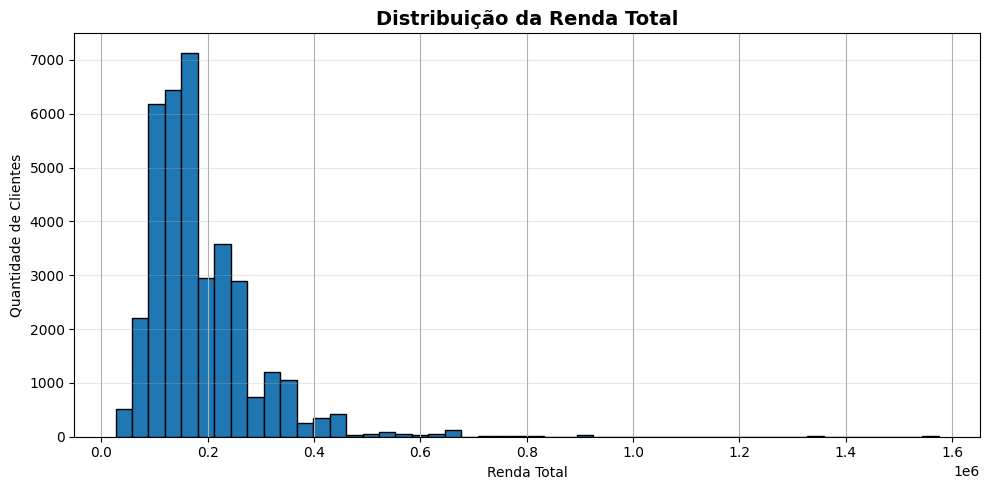

In [37]:
#identificando graficamente a distribuição de dados da renda
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

df_modelb['AMT_INCOME_TOTAL'].hist(
    bins=50,
    edgecolor='black'
)

plt.title('Distribuição da Renda Total', fontsize=14, fontweight='bold')
plt.xlabel('Renda Total')
plt.ylabel('Quantidade de Clientes')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

```
# Observações:
1- Concentração em renda abaixo de 20 mil mas com alguns clientes ganhando até 100 mil
```


In [38]:
# Foi aplicada transformação logarítmica à variável de renda para reduzir sua assimetria.
import numpy as np

df_modelb['AMT_INCOME_TOTAL_LOG'] = np.log1p(df_model['AMT_INCOME_TOTAL'])

In [39]:
df_modelb.head()

,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,...,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Not reported,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,AMT_INCOME_TOTAL_LOG
0,1,1,0,427500.0,1,0,0,2.0,32.9,12.435318,...,0,0,1,0,0,0,0,0,0,12.965712
1,1,1,0,427500.0,1,0,0,2.0,32.9,12.435318,...,0,0,1,0,0,0,0,0,0,12.965712
2,1,1,0,112500.0,0,0,0,2.0,58.8,3.104723,...,0,0,0,0,0,0,0,1,0,11.630717
3,0,1,0,270000.0,0,1,1,1.0,52.3,8.353183,...,0,0,0,0,0,1,0,0,0,12.506181
4,0,1,0,270000.0,0,1,1,1.0,52.3,8.353183,...,0,0,0,0,0,1,0,0,0,12.506181


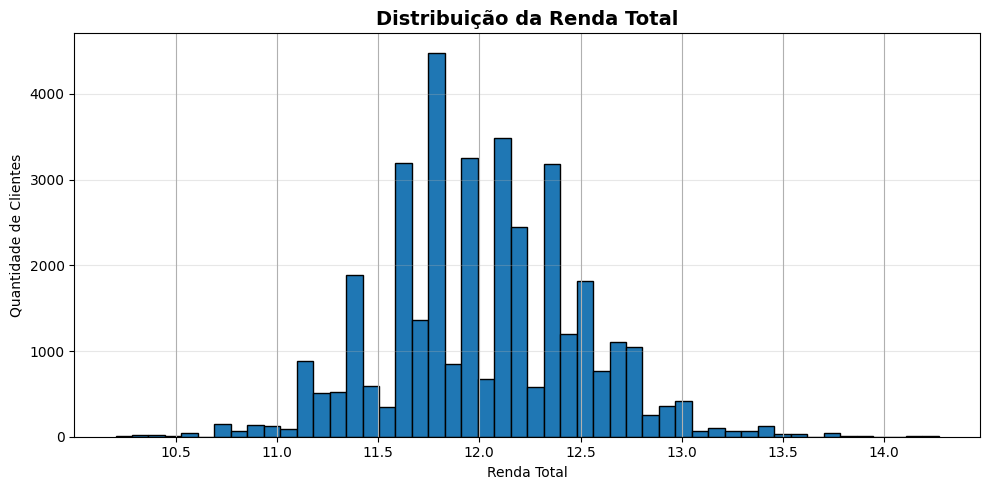

In [40]:
#identificando graficamente a distribuição de dados da renda na escala logarítmica
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

df_modelb['AMT_INCOME_TOTAL_LOG'].hist(
    bins=50,
    edgecolor='black'
)

plt.title('Distribuição da Renda Total', fontsize=14, fontweight='bold')
plt.xlabel('Renda Total')
plt.ylabel('Quantidade de Clientes')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

```
# Observações:
1- renda total balanceada no histograma pela escala logarítmica
```

In [41]:
#-excluir a variável AMT_INCOME_TOTAL(RENDA) do modelo e deixar apenas o seu correspondente AMT_INCOME_TOTAL_LOG
df_modelc = df_modelb.drop(columns=['AMT_INCOME_TOTAL']).copy()

In [42]:
df_modelc.head()

,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,TARGET,...,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Not reported,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,AMT_INCOME_TOTAL_LOG
0,1,1,0,1,0,0,2.0,32.9,12.435318,0,...,0,0,1,0,0,0,0,0,0,12.965712
1,1,1,0,1,0,0,2.0,32.9,12.435318,0,...,0,0,1,0,0,0,0,0,0,12.965712
2,1,1,0,0,0,0,2.0,58.8,3.104723,1,...,0,0,0,0,0,0,0,1,0,11.630717
3,0,1,0,0,1,1,1.0,52.3,8.353183,0,...,0,0,0,0,0,1,0,0,0,12.506181
4,0,1,0,0,1,1,1.0,52.3,8.353183,0,...,0,0,0,0,0,1,0,0,0,12.506181


In [43]:
#verificando a correlação entre a quantidade de membros da família e a quantidade de filhos
df_model[
    ['CNT_CHILDREN',
     'CNT_FAM_MEMBERS']
].corr()

,CNT_CHILDREN,CNT_FAM_MEMBERS
CNT_CHILDREN,1.000000,0.889114
CNT_FAM_MEMBERS,0.889114,1.000000


In [44]:
#excluindo CNT_FAM_MEMBERS do modelo para deixar apenas CNT_CHILDREN
df_modeld = df_modelc.drop(columns=['CNT_FAM_MEMBERS']).copy()

In [45]:
df_modeld.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 52 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   FLAG_OWN_CAR                                       36457 non-null  int64  
 1   FLAG_OWN_REALTY                                    36457 non-null  int64  
 2   CNT_CHILDREN                                       36457 non-null  int64  
 3   FLAG_WORK_PHONE                                    36457 non-null  int64  
 4   FLAG_PHONE                                         36457 non-null  int64  
 5   FLAG_EMAIL                                         36457 non-null  int64  
 6   AGE                                                36457 non-null  float64
 7   YEARS_EMPLOYED                                     36457 non-null  float64
 8   TARGET                                             36457 non-null  int64  
 9   CODE_G

# 1 — Recriando 03 Modelagem

In [46]:
# separar x e y
X = df_modeld.drop(columns=['TARGET'])
y = df_modeld['TARGET']

In [47]:
X.shape

(36457, 51)

In [48]:
y.value_counts(normalize=True) * 100

,proportion
TARGET,
1,56.921853
0,43.078147


## **0 - Split treino/teste**

In [49]:
# stratify=y para garantir que a proporção de bons e maus pagadores seja aproximadamente preservada nos dois conjuntos

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [50]:
# conferindo o balanceamento
y_train.value_counts(normalize=True) * 100

,proportion
TARGET,
1,56.920967
0,43.079033


## **1 -  Modelo 1 - Regressão Logística**

In [51]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [52]:
#escalonamento, SEM fit no conjunto de teste para evitar data leakage
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
# como o modelo é desbalanceado pelo TARGET, class_weight='balanced' para atribuir mais peso a classe minoritária


modelo_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

modelo_lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [54]:
#criar variável de predição
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_prob_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

In [55]:
#acurácia do modelo
accuracye_lr = round(accuracy_score(y_test, y_pred_lr), 4)
print("Acurácia:", accuracye_lr)

Acurácia: 0.5281


## 1.1- Matriz de Confusão do Modelo 1 - Regressão Logística

In [56]:

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

In [57]:

#Matriz de confusão bons classificados como bons; bons classificados como maus;maus classificados como bons; maus classificados como maus.
confusion_matrix(y_test, y_pred_lr)

array([[1613, 1528],
       [1913, 2238]])

In [58]:

# linha 1, precisão para maus pagadores
#ROC-AUC: capacidade do modelo de distinguir as duas classes
#PR-AUC: desempenho sobre a classe positiva quando existe desbalanceamento

print(classification_report(y_test, y_pred_lr))

print(
    'ROC-AUC:',
    roc_auc_score(y_test, y_prob_lr)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, y_prob_lr)
)

              precision    recall  f1-score   support

           0       0.46      0.51      0.48      3141
           1       0.59      0.54      0.57      4151

    accuracy                           0.53      7292
   macro avg       0.53      0.53      0.52      7292
weighted avg       0.54      0.53      0.53      7292

ROC-AUC: 0.5420870726079055
PR-AUC: 0.6061445010368753


## **2 - Modelo 2 - Árvore de Decisão**

In [59]:
#X31
#Decision Tree não depende da escala dos valores para tomar suas decisões, não precisa rodar o StandardScaler
modelo_tree = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=5
)

modelo_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [60]:
#criar variável de valores previstos
y_pred_tree = modelo_tree.predict(X_test)

y_prob_tree = modelo_tree.predict_proba(X_test)[:, 1]


In [61]:
#acurácia do modelo
accuracye_tree = round(accuracy_score(y_test, y_pred_tree), 4)
print("Acurácia:", accuracye_tree)

Acurácia: 0.5646


## 2.1 - Matriz de Confusão do Modelo 2 - Árvore de Decisão**

In [62]:

#Matriz de confusão bons classificados como bons; bons classificados como maus;maus classificados como bons; maus classificados como maus.
confusion_matrix(y_test, y_pred_tree)

array([[1005, 2136],
       [1039, 3112]])

In [63]:

# linha 1, precisão para maus pagadores
#ROC-AUC: capacidade do modelo de distinguir as duas classes
#PR-AUC:  desempenho sobre a classe positiva quando existe desbalanceamento

print(classification_report(y_test, y_pred_tree))

print(
    'ROC-AUC:',
    roc_auc_score(y_test, y_prob_tree)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, y_prob_tree)
)

              precision    recall  f1-score   support

           0       0.49      0.32      0.39      3141
           1       0.59      0.75      0.66      4151

    accuracy                           0.56      7292
   macro avg       0.54      0.53      0.52      7292
weighted avg       0.55      0.56      0.54      7292

ROC-AUC: 0.5523334691640186
PR-AUC: 0.6074716833959807


## **3 - Modelo 3 - Random Forest**

In [64]:

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [65]:
#variável de previsões
y_pred_rf = modelo_rf.predict(X_test)

y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

In [66]:
#acurácia do modelo
accuracye = round(accuracy_score(y_test, y_pred_rf), 4)
print("Acurácia:", accuracye)

Acurácia: 0.6872


## 3.1 Matriz de Confusão do Modelo 3 - Random Forest**

In [67]:

#Matriz de confusão bons classificados como bons; bons classificados como maus;maus classificados como bons; maus classificados como maus.
confusion_matrix(y_test, y_pred_rf)

array([[2041, 1100],
       [1181, 2970]])

In [68]:

# linha 1, precisão para maus pagadores
#ROC-AUC: capacidade do modelo de distinguir as duas classes
#PR-AUC:  desempenho sobre a classe positiva quando existe desbalanceamento

print(classification_report(y_test, y_pred_rf))

print(
    'ROC-AUC:',
    roc_auc_score(y_test, y_prob_rf)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, y_prob_rf)
)

              precision    recall  f1-score   support

           0       0.63      0.65      0.64      3141
           1       0.73      0.72      0.72      4151

    accuracy                           0.69      7292
   macro avg       0.68      0.68      0.68      7292
weighted avg       0.69      0.69      0.69      7292

ROC-AUC: 0.7473074116845528
PR-AUC: 0.7706366806136553


### **4 - Modelo 4 - Gradient Boosting**






In [69]:
modelo_gb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=42
)

modelo_gb.fit(X_train, y_train)

HistGradientBoostingClassifier(learning_rate=0.05, max_iter=200,
                               max_leaf_nodes=15, random_state=42)

In [70]:
#variável de predição
y_pred_gb = modelo_gb.predict(X_test)

y_prob_gb = modelo_gb.predict_proba(X_test)[:, 1]

In [71]:
#acurácia do modelo
accuracye = round(accuracy_score(y_test, y_pred_gb), 4)
print("Acurácia:", accuracye)

Acurácia: 0.6081


## 4.1 - Matriz de Confusão do Modelo 3 - Random Forest**

In [72]:
#Matriz de confusão bons classificados como bons; bons classificados como maus;maus classificados como bons; maus classificados como maus.
confusion_matrix(y_test, y_pred_gb)

array([[ 544, 2597],
       [ 261, 3890]])

In [73]:
# linha 1, precisão para maus pagadores
#ROC-AUC: capacidade do modelo de distinguir as duas classes
#PR-AUC:  desempenho sobre a classe positiva quando existe desbalanceamento

print(classification_report(y_test, y_pred_gb))

print(
    'ROC-AUC:',
    roc_auc_score(y_test, y_prob_gb)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, y_prob_gb)
)

              precision    recall  f1-score   support

           0       0.68      0.17      0.28      3141
           1       0.60      0.94      0.73      4151

    accuracy                           0.61      7292
   macro avg       0.64      0.56      0.50      7292
weighted avg       0.63      0.61      0.54      7292

ROC-AUC: 0.6244291525630161
PR-AUC: 0.6728016533651353


## **2 - Inicio da Avaliação Interpretação**

**Considerando o desbalanceamento da variável TARGET, a escolha do modelo não foi baseada apenas na acurácia. Foram considerados principalmente Precision, Recall, F1-score, ROC-AUC e PR-AUC para avaliar a capacidade de identificação dos clientes classificados como de maior risco.

Entre os modelos avaliados, o Random Forest apresentou o melhor desempenho geral, com ROC-AUC de 0,74 e PR-AUC de 0,77, além de Precision de 0,73, Recall de 0,72 e F1-score de 0,72.

Embora o Gradient Boosting tenha apresentado valores ligeiramente superiores de Recall (0,74) e F1-score (0,73), o Random Forest apresentou desempenho superior nas métricas de discriminação geral e, principalmente, na PR-AUC, métrica particularmente relevante em cenários de classes desbalanceadas.

Dessa forma, o Random Forest foi selecionado como modelo final por apresentar o melhor equilíbrio entre capacidade de discriminação, precisão na identificação dos clientes de maior risco e desempenho sobre a classe minoritária..**

| Modelo           | Accur. |  Precision1 | Recall1 | F1 1 | ROC-AUC | PR-AUC|
| ---------------- | -----: |  ---------: | ------: | ---: | -----:  | -----:|
| Logistic Regres. | 0.53   |  0.59       | 0.54    | 0.57 | 0.54    | 0.60  |
| Decision Tree    | 0.56   |  0.59       | 0.75    | 0.66 | 0.55    | 0.60  |
| Random Forest    | 0.69   |  0.73       | 0.72    | 0.72 | 0.74    | 0.77  |
| Gradient Boost.  | 0.61   |  0.60       | 0.74    | 0.73 | 0.62    | 0.67  |




## 9. 1 Threshold (limiar): qual probablidade prevista no Random Forest vais ser o ponto de corte para ativar o Target.

In [74]:
#Lista de precisão do modelo por probabilidade:
#Precision = % dos clientes considerados de maior risco pelo modelo que realmente são de maior risco
#Recall = % dos clientes de maior risco que realmente foram identificados (Se o objetivo do banco for não deixar passar maus pagadores, aceirar Recall maior mesmo que com menor Precision.)
#F1-score = métrica que busca medir o equilíbrio entre Precision e Recall.
thresholds = np.arange(0.10, 0.75, 0.05)

resultados_threshold = []

for threshold in thresholds:

    y_pred = (y_prob_rf >= threshold).astype(int)

    resultados_threshold.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

df_threshold = pd.DataFrame(resultados_threshold)

df_threshold

,Threshold,Precision,Recall,F1
0,0.10,0.623017,0.965069,0.757206
1,0.15,0.635370,0.952060,0.762125
2,0.20,0.647570,0.933992,0.764845
3,0.25,0.667555,0.905083,0.768381
4,0.30,0.678142,0.882679,0.767009
5,0.35,0.690243,0.848711,0.761318
6,0.40,0.695992,0.815707,0.751109
7,0.45,0.708719,0.775476,0.740596
8,0.50,0.729730,0.715490,0.722540
9,0.55,0.739719,0.658636,0.696827


```
# Observações:
1- Após a seleção do Random Forest, foram avaliados diferentes valores de threshold para analisar o impacto do ponto de corte sobre Precision, Recall e F1-score.

O threshold de **0,10** foi selecionado com o objetivo de aumentar a capacidade de identificação dos clientes classificados como de maior risco. Nesse ponto de corte, o modelo alcançou **Recall de 96,5%**, indicando que consegue identificar a maior parte dos clientes pertencentes à classe de maior risco.

Decisão de negócio: essa escolha implica aceitar uma maior quantidade de falsos positivos e, consequentemente, uma possível redução da Precision. Em um contexto de análise de crédito, essa estratégia pode ser adequada quando o custo de deixar passar um cliente de maior risco é considerado superior ao custo de realizar uma análise adicional de clientes classificados preventivamente como de risco.
```

In [75]:


importancias = pd.DataFrame({
    'Variavel': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancias = (
    importancias
    .sort_values('Importancia', ascending=False)
    .reset_index(drop=True)
)

importancias.head(10)

,Variavel,Importancia
0,AGE,0.229486
1,AMT_INCOME_TOTAL_LOG,0.168704
2,YEARS_EMPLOYED,0.157629
3,CNT_CHILDREN,0.040161
4,FLAG_OWN_CAR,0.026842
5,FLAG_PHONE,0.026302
6,FLAG_OWN_REALTY,0.026007
7,FLAG_WORK_PHONE,0.021822
8,OCCUPATION_TYPE_Not reported,0.015210
9,NAME_EDUCATION_TYPE_Secondary / secondary special,0.015199


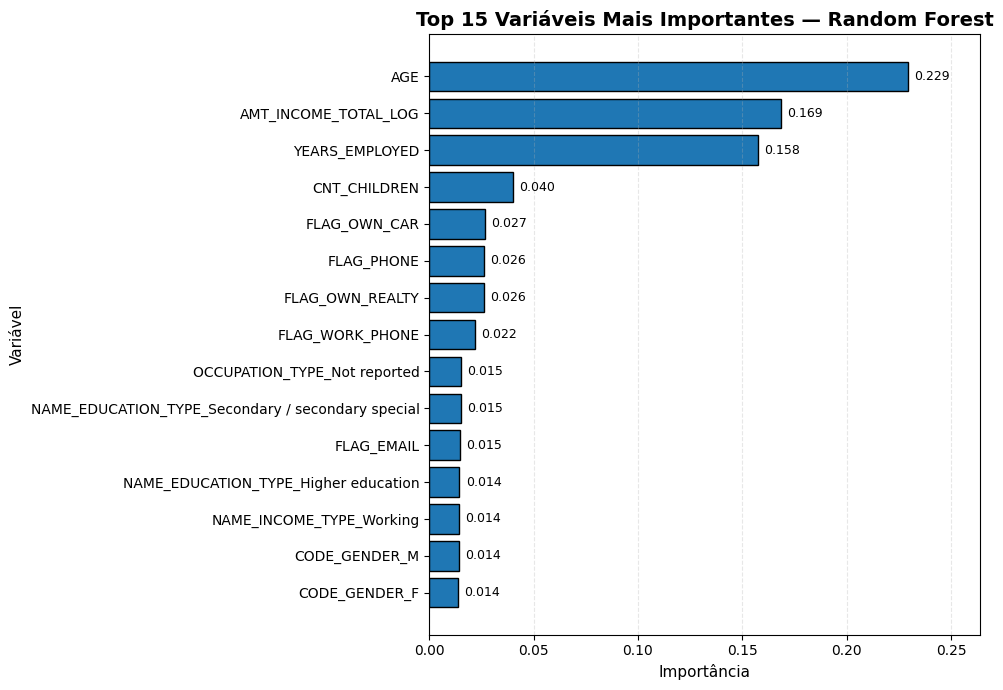

In [76]:
#importância das variáveis
# Importância das variáveis - Random Forest

import pandas as pd
import matplotlib.pyplot as plt

# Criando DataFrame com as importâncias
importancias = pd.DataFrame({
    'Variavel': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
})

# Ordenando da maior para a menor importância
importancias = (
    importancias
    .sort_values('Importancia', ascending=False)
    .reset_index(drop=True)
)

# Selecionando as 15 mais importantes
top15 = importancias.head(15).sort_values('Importancia')

# Criando o gráfico
plt.figure(figsize=(10, 7))

barras = plt.barh(
    top15['Variavel'],
    top15['Importancia'],
    edgecolor='black'
)

# Adicionando os valores nas barras
for barra in barras:
    valor = barra.get_width()

    plt.text(
        valor + 0.003,
        barra.get_y() + barra.get_height() / 2,
        f'{valor:.3f}',
        va='center',
        fontsize=9
    )

plt.xlabel('Importância', fontsize=11)
plt.ylabel('Variável', fontsize=11)

plt.title(
    'Top 15 Variáveis Mais Importantes — Random Forest',
    fontsize=14,
    fontweight='bold'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.xlim(0, top15['Importancia'].max() * 1.15)

plt.tight_layout()
plt.show()

```

# Observações:
1- A análise da importância das variáveis do modelo Random Forest mostrou que
 as características com maior contribuição para a capacidade preditiva foram
 AGE (22,9%), AMT_INCOME_TOTAL_LOG (16,9%) e YEARS_EMPLOYED (15,8%). Em
 conjunto, essas três variáveis representam aproximadamente 55% da
 importância total atribuída pelo modelo.


CNT_CHILDREN (4,0%) e FLAG_PHONE (2,7%), com contribuições menores, porém
ainda relevantes para as decisões do modelo.

Os resultados sugerem, assim, que o perfil socioeconômico e a estabilidade
do solicitante são variáveis que apresentaram maior importância para as decisões preditivas do modelo
realizada pelo modelo.
```
